# Lazy `DatasetCollection` — complete cookbook

A `DatasetCollection` stacks per-file reads into a single 4-D `(T, B, R, C)` lazy `dask.array.Array`. Each timestep is opened on demand through `CachingFileManager`, so workers never serialise a live `gdal.Dataset` handle — only the file path crosses the pickle boundary.

This notebook exercises the **full** collection surface against local test data:

1. `DatasetCollection.from_files(...)` — construct without opening every file eagerly.
2. `collection.data` — the 4-D lazy cube.
3. Built-in reductions (`mean` / `sum` / `min` / `max` / `std` / `var`).
4. `collection.groupby(labels)` — per-group reductions (monthly means, seasonal climatologies).
5. `collection.meta` — the picklable `RasterMeta` snapshot.
6. `collection.to_zarr(store)` — parallel cube write.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'
```

## Setup — imports and the data path

`%matplotlib inline` draws plots inline. We import `numpy` (used to build a per-timestep label array later) and
resolve `DATA` to the repo's `examples/data/` folder, relative to this notebook. All rasters are read locally.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

DATA = (Path('..') / '..' / '..' / 'examples' / 'data').resolve()
DATA.is_dir()

True

## 1. Build a synthetic stack

The pyramids test suite has a folder of aligned rasters under `examples/data/crop_aligned_folder/` — 6 rasters with the same geobox, different values. Perfect for a short cube.

In [2]:
# 6 aligned rasters named 0.tif..5.tif — same geobox, different values.
folder = DATA / 'crop_aligned_folder'
files = sorted(folder.glob('[0-5].tif'))
[f.name for f in files]

['0.tif', '1.tif', '2.tif', '3.tif', '4.tif', '5.tif']

`from_files` builds the collection from that file list **without opening every raster** — it reads one template
for the geobox and defers the rest. `time_length`, `rows`, and `columns` come from that lightweight construction:

In [3]:
from pyramids.dataset import DatasetCollection

cube = DatasetCollection.from_files(files)
cube.time_length, cube.rows, cube.columns

2026-07-01 16:38:41 | INFO | pyramids.base.config | Logging is configured.


(6, 24, 29)

### Peek at one timestep

The cube is lazy, but each timestep is a concrete raster. `iloc(0)` materialises the first slice as a `Dataset` so we can plot it — a quick visual check before reducing across time.

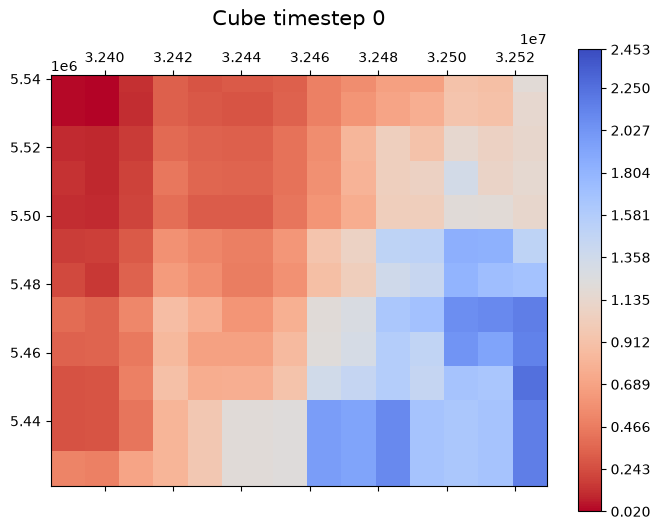

In [4]:
cube.iloc(0).plot(band=0, title="Cube timestep 0")

`iloc(0)` pulled a single timestep back as an eager `Dataset` purely for this visual check — the cube as a whole
stays lazy. Next we look at the 4-D lazy array that backs all six timesteps at once.

## 2. The lazy 4-D cube — `collection.data`

`collection.data` is a `dask.array.Array` of shape `(T, B, R, C)`. Every per-file read is a `dask.delayed` task that opens the file via `CachingFileManager`.

In [5]:
cube.data.shape, cube.data.dtype

((6, 1, 24, 29), dtype('float32'))

The cube is `(T=6, B=1, R=24, C=29)`. Its chunking tells you how the graph is partitioned across timesteps:

In [6]:
# Chunks are one-timestep-per-chunk by default —
# the delayed-based graph reads a whole file at a time.
cube.data.chunks

((1, 1, 1, 1, 1, 1), (1,), (24,), (29,))

## 3. Built-in reductions

Six reductions ship directly on the collection so you don't have to write `.data.nanmean(axis=0).compute()`
every time. Each collapses the time axis and returns a `numpy.ndarray` of shape `(B, R, C)` after a single
`.compute()`:

| Reductions | NaN handling | Returns |
|---|---|---|
| `mean` / `sum` / `min` / `max` / `std` / `var` | `skipna=True` skips nodata | `(B, R, C)` ndarray |

In [7]:
time_mean = cube.mean(skipna=True)
time_sum = cube.sum(skipna=True)
type(time_mean).__name__, time_mean.shape

('ndarray', (1, 24, 29))

`mean` returned a concrete `(B, R, C)` array — one `.compute()` collapsed the time axis. The same holds for
`std` and `var`; below we sample four reductions and reduce each to a single scalar for a compact summary:

In [8]:
# std / var are also available
stats = {
    'min': float(cube.min().min()),
    'max': float(cube.max().max()),
    'mean': float(cube.mean().mean()),
    'std': float(cube.std().mean()),
}
stats

{'min': 0.0,
 'max': 5.150000095367432,
 'mean': 0.6656417846679688,
 'std': 1.144860863685608}

## 4. Grouped reductions — `groupby(labels)`

Pass a per-timestep label array and get `{label: array}`. Pyramids routes through **flox** for the single-pass grouped reduction when the `[lazy]` extra is installed; otherwise it falls back to a per-label loop with equivalent semantics.

In [9]:
# Synthetic label array — group timesteps into two buckets.
labels = np.array(['A', 'A', 'A', 'B', 'B', 'B'][: cube.time_length])
grouped = cube.groupby(labels)
group_means = grouped.mean()
sorted(group_means.keys()), group_means['A'].shape

([np.str_('A'), np.str_('B')], (1, 24, 29))

`groupby` returned one array per label. Timesteps `0-2` landed in group `A` and `3-5` in group `B`, and each
value is the per-pixel mean within its group — the pattern behind monthly means or seasonal climatologies.

## 5. `collection.meta` — the picklable `RasterMeta` snapshot

Every collection caches a frozen `RasterMeta` of the template file's geobox + dtype + nodata. It's the single place the lazy paths read metadata from — no GDAL opens per call, and the collection pickles cleanly for `dask.distributed`.

In [10]:
meta = cube.meta
(
    meta.epsg,
    meta.shape,
    meta.cell_size,
    meta.nodata,
    meta.dtype,
)

(4647, (1, 24, 29), 5000.0, (2147483648.0,), 'float32')

Because `meta` is a plain frozen snapshot (no live GDAL handle), it pickles cleanly — the property that lets a
whole collection travel to `dask.distributed` workers intact:

In [11]:
# The snapshot is picklable — ship across dask workers.
import pickle

restored = pickle.loads(pickle.dumps(meta))
restored == meta

True

## 6. Parallel cube write — `collection.to_zarr`

Each dask chunk in `collection.data` lands in an independent Zarr chunk file. The store carries pyramids + rioxarray attributes (`epsg`, `crs_wkt`, `GeoTransform`, `nodata`, `band_names`, `time_length`, source file list), so downstream `xr.open_zarr` consumers can reconstruct the geobox without pyramids.

In [12]:
import tempfile

workdir = Path(tempfile.mkdtemp(prefix='pyramids-cube-'))
store = workdir / 'cube.zarr'
cube.to_zarr(store, mode='w')
sorted(p.name for p in store.iterdir())

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

Each dask chunk became an independent Zarr chunk file. The root `zarr.json` carries the pyramids + rioxarray
attributes, so any Zarr/xarray consumer can reconstruct the geobox without pyramids:

In [13]:
# Inspect the metadata — readable by any Zarr/xarray consumer. Zarr v3 keeps
# attributes under the "attributes" key of the store's root zarr.json.
import json

root_attrs = json.loads((store / 'zarr.json').read_text())['attributes']
root_attrs['pyramids_zarr_version'], root_attrs['time_length']

('2', 6)

## Closing notes

- `from_stac(items, asset='B04')` is the STAC variant — same cube, different source. Works on any duck-typed STAC-like iterable (pystac.Item, raw JSON dicts, ...); no pyramids extra required.
- `to_kerchunk(path, concat_dim='time')` emits a JSON index for NetCDF/HDF5 cubes; GeoTIFF is tracked as a follow-on.
- For a cloud-hosted Sentinel-2 walkthrough, see `dask-lazy-datasets.ipynb` (pairs STAC search with `from_stac`).